# 04. Miyazaki型シグナルの長期バックテスト比較

このノートブックでは、`02_miyazaki.ipynb` の考え方を長期バックテストへ拡張し、前回作成した月次平均回帰戦略と同じデータ・同じ実現リターン定義で比較する。

目的は、以下を切り分けること。

- `miyazaki` 型の半年CA&RDシグナルは長期でも有効か
- 3因子モデルの誤差項を使う提案手法は単純CA&RDより良いか
- 前回の新提案戦略（1か月ホライズンの残差平均回帰）と比べてどうか
- 以前の `02_miyazaki.ipynb` が良く見えた理由が、シグナルの力なのか、期間・リターン定義の違いなのか

比較の公平性を保つため、全戦略で以下を共通にする。

- データ: `data/us_treasury_yields_2004_2026.xlsx`
- バックテスト: 2006年4月末シグナル、2006年5月末〜2026年3月末リターン
- 実現リターン: 1か月保有の債券価格リターン
- ベンチマーク: 13セクター等加重
- 制約: ロングオンリー、完全投資、BMへのデュレーション一致
- 因子分析: 各月、過去24か月だけでローリング推定

## セットアップ

長期データは前回ノートブックで作成済みのExcelを使う。必要なら `03_us_treasury_monthly_strategy_2006_2026.ipynb` を再実行して更新できる。

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import linprog
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401

from performance import calc_tracking_error, calc_win_rate

DATA_PATH = Path("../data/us_treasury_yields_2004_2026.xlsx")
RESULT_PATH = Path("../data/backtest_miyazaki_long_comparison.xlsx")

CURVE_NODES = np.array([0.5, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
MATURITIES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30], dtype=float)
SECTOR_NAMES = ["1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "15Y", "20Y", "30Y"]
N_SECTORS = len(MATURITIES)

LOOKBACK_MONTHS = 24
BACKTEST_START = pd.Timestamp("2006-04-30")
BACKTEST_LAST_SIGNAL = pd.Timestamp("2026-02-28")

# Miyazaki型シグナルは論文/02_miyazakiと同じ半年CA&RDを使う。
MIYAZAKI_SIGNAL_HORIZON = 0.5
MIYAZAKI_GAMMA = 0.5

# 前回提案戦略は月次ホライズンで、6か月半減ペースの平均回帰を使う。
RESIDUAL_HALF_LIFE_MONTHS = 6
MONTHLY_GAMMA = 1 - 0.5 ** (1 / RESIDUAL_HALF_LIFE_MONTHS)

MAX_WEIGHT = 0.35
MAX_SECTOR_TRADE = 0.15
TRANSACTION_COST_BPS = 2.0

print(f"Miyazaki gamma: {MIYAZAKI_GAMMA:.3f}")
print(f"Monthly residual gamma: {MONTHLY_GAMMA:.4f}")

Miyazaki gamma: 0.500
Monthly residual gamma: 0.1091


## 共通データの読み込み

13セクター利回りと、1か月ロールダウン評価に使う元のカーブノードを読み込む。1Yを1か月保有したあとは1年未満に入るため、カーブノードには6か月金利も含めている。

In [2]:
yields = pd.read_excel(DATA_PATH, sheet_name="yields", index_col=0, parse_dates=True)
curve_nodes = pd.read_excel(DATA_PATH, sheet_name="source_nodes", index_col=0, parse_dates=True)

yields = yields[SECTOR_NAMES]

print(f"利回りデータ: {yields.index[0].date()}〜{yields.index[-1].date()}, shape={yields.shape}")
print(f"カーブノード: {list(curve_nodes.columns)}")
print(f"欠損セル数: {int(yields.isna().sum().sum())}")
display(yields.head())

利回りデータ: 2004-04-30〜2026-03-31, shape=(264, 13)
カーブノード: ['0.5Y', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
欠損セル数: 0


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2004-04-30,1.55,2.31,2.86,3.286065,3.63,3.899695,4.11,4.276746,4.412732,4.53,5.005480,5.31,5.39
2004-05-31,1.83,2.54,3.10,3.508535,3.81,4.057056,4.26,4.420717,4.549795,4.66,5.106920,5.39,5.42
2004-06-30,2.09,2.70,3.16,3.521538,3.81,4.047297,4.24,4.392406,4.515043,4.62,5.049335,5.33,5.41
2004-07-31,2.13,2.68,3.09,3.427687,3.71,3.942585,4.13,4.277863,4.397109,4.50,4.937441,5.24,5.31
2004-08-31,1.99,2.41,2.75,3.053891,3.33,3.566822,3.76,3.909852,4.028262,4.13,4.586864,4.93,5.01


## 債券価格と月次実現リターン

実現リターンは全戦略で同じ1か月保有リターンを使う。時点 $t$ のパー債を翌月末 $t+1$ に評価し、売却するイメージである。

一方、従来の `miyazaki` 型シグナルは、論文・既存ノートブックに近い半年CA&RDを使う。つまり、シグナルと実現リターンのホライズンは意図的に分ける。これは「半年CA&RDを月次リバランスの順位付けシグナルとして使う」設計である。

今回追加する `Miyazaki_Monthly` は、宮崎論文のCA&RD+誤差項補正の考え方を保ちながら、シグナルホライズンも実現リターンと同じ1か月にそろえる。具体的には、ロールダウン先を $T_i-0.5$ ではなく $T_i-\Delta_t$ とし、半年で50%修正される誤差項を1か月分の修正率へ換算する。

In [3]:
def year_fraction(start, end):
    return (end - start).days / 365.25


def cashflow_times(original_maturity, elapsed=0.0, freq=2):
    payment_times = np.arange(1 / freq, original_maturity + 1e-9, 1 / freq) - elapsed
    return payment_times[payment_times > 1e-10]


def price_bond_elapsed(y_coupon, y_discount, original_maturity, elapsed=0.0, freq=2):
    times = cashflow_times(original_maturity, elapsed=elapsed, freq=freq)
    if len(times) == 0:
        return 100.0
    coupon = y_coupon * 100 / freq
    cashflows = np.full(len(times), coupon)
    cashflows[-1] += 100
    return float(np.sum(cashflows / (1 + y_discount / freq) ** (freq * times)))


def dP_dy(y_coupon, y_discount, maturity, freq=2, dy=1e-5):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - p_down) / (2 * dy)


def d2P_dy2(y_coupon, y_discount, maturity, freq=2, dy=1e-4):
    p_up = price_bond_elapsed(y_coupon, y_discount + dy, maturity, elapsed=0.0, freq=freq)
    p0 = price_bond_elapsed(y_coupon, y_discount, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y_coupon, y_discount - dy, maturity, elapsed=0.0, freq=freq)
    return (p_up - 2 * p0 + p_down) / dy**2


def modified_duration(y, maturity, freq=2, dy=1e-4):
    p0 = price_bond_elapsed(y, y, maturity, elapsed=0.0, freq=freq)
    p_up = price_bond_elapsed(y, y + dy, maturity, elapsed=0.0, freq=freq)
    p_down = price_bond_elapsed(y, y - dy, maturity, elapsed=0.0, freq=freq)
    return -(p_up - p_down) / (2 * dy) / p0


def realized_sector_returns(row_sector_pct, next_node_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    next_curve = CubicSpline(CURVE_NODES, next_node_pct.astype(float) / 100, extrapolate=True)

    returns = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        y_next = float(next_curve(maturity - horizon))
        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_next, maturity, elapsed=horizon)
        returns.append(p1 / p0 - 1)
    return np.array(returns)


for maturity in [1, 5, 10, 30]:
    print(f"{maturity:>2}Y par price @ 3%: {price_bond_elapsed(0.03, 0.03, maturity):.6f}")

 1Y par price @ 3%: 100.000000
 5Y par price @ 3%: 100.000000
10Y par price @ 3%: 100.000000
30Y par price @ 3%: 100.000000


## ローリング3因子モデル

各月のシグナル計算では、過去24か月だけを使って標準化済み利回りに因子分析を行う。そのローディングを使い、時点 $t$ のモデル利回りと誤差項を推定する。

この処理は `02_miyazaki.ipynb` の因子分析の考え方を、長期バックテストで先読みしない形に拡張したもの。

In [4]:
def fit_factor_model(history_pct):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(history_pct.values.astype(float))
    fa = FactorAnalysis(n_components=3, random_state=42, max_iter=2000)
    fa.fit(scaled)
    loadings = fa.components_.T
    return scaler, loadings


def estimate_model_yield(y_pct, scaler, loadings):
    y_scaled = scaler.transform(y_pct.reshape(1, -1)).ravel()
    factor_values = np.linalg.lstsq(loadings, y_scaled, rcond=None)[0]
    model_scaled = loadings @ factor_values
    model_pct = model_scaled * scaler.scale_ + scaler.mean_
    residual_pct = y_pct - model_pct
    return model_pct, residual_pct, factor_values

## シグナル定義

比較する戦略は以下。

- `MZ_CARD`: `02_miyazaki` の①に近い、実際利回りの半年CA&RD
- `MZ_MODEL`: `02_miyazaki` の②に近い、3因子モデル利回りの半年CA&RD
- `MZ_ALPHA`: `02_miyazaki` の③に近い、誤差項の半分が半年で修正される想定
- `MZ_ALPHA_cap35`: `MZ_ALPHA` に1セクター35%上限を加えた版
- `Miyazaki_Monthly`: Miyazaki型のCA&RD+誤差項補正を1か月ホライズンで再計算した版
- `Miyazaki_Monthly_cap35`: `Miyazaki_Monthly` に1セクター35%上限を加えた版
- `OUR_REV_cap35`: 前回提案の月次残差平均回帰シグナル + 35%上限
- `OUR_REV_smooth15`: `OUR_REV_cap35` に月次セクター売買15%上限を加えた版

`Miyazaki_Monthly` の誤差項修正率は、半年で50%修正されるという宮崎論文の前提を維持し、1か月ホライズン $\Delta_t$ に対して

$$
\gamma_{\Delta_t}
=
1-(1-0.5)^{\Delta_t/0.5}
$$

とする。

In [5]:
def calc_miyazaki_card_taylor(y_i, delta_y, maturity, signal_horizon=MIYAZAKI_SIGNAL_HORIZON):
    p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
    rolled_maturity = max(maturity - signal_horizon, 0.5)
    carry = y_i * 100 * signal_horizon
    duration_term = dP_dy(y_i, y_i, rolled_maturity) * delta_y
    convexity_term = 0.5 * d2P_dy2(y_i, y_i, rolled_maturity) * delta_y**2
    return (carry + duration_term + convexity_term) / p0


def residual_gamma_for_horizon(horizon, base_gamma=MIYAZAKI_GAMMA, base_horizon=MIYAZAKI_SIGNAL_HORIZON):
    return 1 - (1 - base_gamma) ** (horizon / base_horizon)


def miyazaki_style_signals(row_sector_pct, row_node_pct, model_pct, residual_pct, gamma=MIYAZAKI_GAMMA):
    y_current = row_sector_pct.astype(float) / 100
    actual_curve = CubicSpline(CURVE_NODES, row_node_pct.astype(float) / 100, extrapolate=True)
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)

    signals = {"MZ_CARD": [], "MZ_MODEL": [], "MZ_ALPHA": []}
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        rolled_maturity = max(maturity - MIYAZAKI_SIGNAL_HORIZON, 0.5)
        model_i = model_pct[k] / 100
        eps_i = residual_pct[k] / 100

        delta_card = float(actual_curve(rolled_maturity)) - y_i
        delta_model = float(model_curve(rolled_maturity)) - model_i
        delta_alpha = float(model_curve(rolled_maturity)) - (model_i + gamma * eps_i)

        signals["MZ_CARD"].append(calc_miyazaki_card_taylor(y_i, delta_card, maturity))
        signals["MZ_MODEL"].append(calc_miyazaki_card_taylor(y_i, delta_model, maturity))
        signals["MZ_ALPHA"].append(calc_miyazaki_card_taylor(y_i, delta_alpha, maturity))

    return {name: np.array(values) for name, values in signals.items()}


def miyazaki_monthly_signal(row_sector_pct, model_pct, residual_pct, horizon):
    y_current = row_sector_pct.astype(float) / 100
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)
    gamma_h = residual_gamma_for_horizon(horizon)

    signals = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        rolled_maturity = max(maturity - horizon, 0.5)
        model_i = model_pct[k] / 100
        eps_i = residual_pct[k] / 100
        delta_alpha = float(model_curve(rolled_maturity)) - (model_i + gamma_h * eps_i)
        signals.append(calc_miyazaki_card_taylor(y_i, delta_alpha, maturity, signal_horizon=horizon))

    return np.array(signals)


def monthly_reversion_signal(row_sector_pct, model_pct, residual_pct, horizon, gamma=MONTHLY_GAMMA):
    y_current = row_sector_pct.astype(float) / 100
    model_curve = CubicSpline(MATURITIES, model_pct.astype(float) / 100, extrapolate=True)

    signals = []
    for k, maturity in enumerate(MATURITIES):
        y_i = y_current[k]
        model_i = model_pct[k] / 100
        eps_i = residual_pct[k] / 100
        y_horizon = y_i + (float(model_curve(maturity - horizon)) - model_i - gamma * eps_i)

        p0 = price_bond_elapsed(y_i, y_i, maturity, elapsed=0.0)
        p1 = price_bond_elapsed(y_i, y_horizon, maturity, elapsed=horizon)
        signals.append(p1 / p0 - 1)

    return np.array(signals)

## 最適化と評価指標

全戦略で、ロングオンリー、完全投資、等加重BMへのデュレーション一致を課す。`cap35`系はセクター上限35%、`smooth15`はさらに前月ウエイトから各セクター15%以上動かさない制約を使う。

In [6]:
def optimize_weights(signal, durations, target_duration, max_weight=1.0, prev_weight=None, max_sector_trade=None):
    bounds = []
    for i in range(N_SECTORS):
        lo, hi = 0.0, max_weight
        if prev_weight is not None and max_sector_trade is not None:
            lo = max(lo, prev_weight[i] - max_sector_trade)
            hi = min(hi, prev_weight[i] + max_sector_trade)
        bounds.append((lo, hi))

    a_eq = np.vstack([np.ones(N_SECTORS), durations])
    b_eq = np.array([1.0, target_duration])
    res = linprog(-signal, A_eq=a_eq, b_eq=b_eq, bounds=bounds, method="highs")

    if not res.success and prev_weight is not None:
        # 平滑化制約だけ外すフォールバック。デュレーション一致と上限は維持する。
        res = linprog(-signal, A_eq=a_eq, b_eq=b_eq, bounds=[(0.0, max_weight)] * N_SECTORS, method="highs")

    if not res.success:
        raise RuntimeError(res.message)
    return res.x


def one_way_turnover(new_weight, old_weight):
    return 0.5 * np.abs(new_weight - old_weight).sum()


def apply_transaction_cost(gross_return, turnover, tc_bps=TRANSACTION_COST_BPS):
    return gross_return - turnover * tc_bps / 10000


def annualized_return(ret):
    ret = pd.Series(ret).dropna()
    return (1 + ret).prod() ** (12 / len(ret)) - 1


def annualized_vol(ret):
    return pd.Series(ret).dropna().std(ddof=1) * np.sqrt(12)


def max_drawdown(ret):
    wealth = (1 + pd.Series(ret).dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def summarize_performance(returns, benchmark_col="BM_equal"):
    rows = []
    benchmark = returns[benchmark_col]
    for col in returns.columns:
        r = returns[col].dropna()
        row = {
            "年率リターン(幾何)": annualized_return(r),
            "年率ボラ": annualized_vol(r),
            "最大DD": max_drawdown(r),
        }
        if col != benchmark_col:
            alpha = r - benchmark.reindex(r.index)
            te = calc_tracking_error(alpha)
            row.update({
                "年率超過(算術)": alpha.mean() * 12,
                "TE": te,
                "IR": np.nan if te == 0 else alpha.mean() * 12 / te,
                "勝率": calc_win_rate(alpha),
            })
        rows.append(pd.Series(row, name=col))
    return pd.DataFrame(rows)


def format_performance_table(summary):
    out = summary.copy()
    for col in out.columns:
        if col != "IR":
            out[col] = out[col] * 100
    return out.round(2)

## バックテスト実行

時点 $t$ の情報でシグナルとウエイトを決め、翌月 $t+1$ の実現リターンを記録する。ここで使う翌月利回りは、実現リターン計算にのみ使う。

In [7]:
strategy_names = [
    "BM_equal",
    "MZ_CARD",
    "MZ_MODEL",
    "MZ_ALPHA",
    "MZ_ALPHA_cap35",
    "Miyazaki_Monthly",
    "Miyazaki_Monthly_cap35",
    "OUR_REV_cap35",
    "OUR_REV_smooth15",
]

returns_gross = {name: [] for name in strategy_names}
returns_net = {name: [] for name in strategy_names}
weights = {name: [] for name in strategy_names if name != "BM_equal"}
turnovers = {name: [] for name in strategy_names if name != "BM_equal"}
residual_store = []
rebalance_dates = []

prev_weights = {name: np.ones(N_SECTORS) / N_SECTORS for name in weights}
all_dates = yields.index

for dt in all_dates[:-1]:
    if dt < BACKTEST_START or dt > BACKTEST_LAST_SIGNAL:
        continue

    loc = all_dates.get_loc(dt)
    history = yields.iloc[loc - LOOKBACK_MONTHS:loc]
    if len(history) < LOOKBACK_MONTHS:
        continue

    next_dt = all_dates[loc + 1]
    horizon = year_fraction(dt, next_dt)

    row_sector = yields.loc[dt].values.astype(float)
    row_nodes = curve_nodes.loc[dt].values.astype(float)
    next_nodes = curve_nodes.loc[next_dt].values.astype(float)

    scaler, loadings = fit_factor_model(history)
    model_pct, residual_pct, factor_values = estimate_model_yield(row_sector, scaler, loadings)

    durations = np.array([modified_duration(row_sector[k] / 100, maturity) for k, maturity in enumerate(MATURITIES)])
    benchmark_weight = np.ones(N_SECTORS) / N_SECTORS
    benchmark_duration = benchmark_weight @ durations

    realized = realized_sector_returns(row_sector, next_nodes, horizon)
    miyazaki_signals = miyazaki_style_signals(row_sector, row_nodes, model_pct, residual_pct)
    miyazaki_monthly = miyazaki_monthly_signal(row_sector, model_pct, residual_pct, horizon)
    our_signal = monthly_reversion_signal(row_sector, model_pct, residual_pct, horizon)

    signal_map = {
        "MZ_CARD": (miyazaki_signals["MZ_CARD"], 1.0, None),
        "MZ_MODEL": (miyazaki_signals["MZ_MODEL"], 1.0, None),
        "MZ_ALPHA": (miyazaki_signals["MZ_ALPHA"], 1.0, None),
        "MZ_ALPHA_cap35": (miyazaki_signals["MZ_ALPHA"], MAX_WEIGHT, None),
        "Miyazaki_Monthly": (miyazaki_monthly, 1.0, None),
        "Miyazaki_Monthly_cap35": (miyazaki_monthly, MAX_WEIGHT, None),
        "OUR_REV_cap35": (our_signal, MAX_WEIGHT, None),
        "OUR_REV_smooth15": (our_signal, MAX_WEIGHT, MAX_SECTOR_TRADE),
    }

    rebalance_dates.append(next_dt)
    bm_return = benchmark_weight @ realized
    returns_gross["BM_equal"].append(bm_return)
    returns_net["BM_equal"].append(bm_return)

    for name, (signal, max_weight, max_trade) in signal_map.items():
        weight = optimize_weights(
            signal=signal,
            durations=durations,
            target_duration=benchmark_duration,
            max_weight=max_weight,
            prev_weight=prev_weights[name],
            max_sector_trade=max_trade,
        )
        turnover = one_way_turnover(weight, prev_weights[name])
        gross_return = weight @ realized
        net_return = apply_transaction_cost(gross_return, turnover)

        weights[name].append(weight)
        turnovers[name].append(turnover)
        returns_gross[name].append(gross_return)
        returns_net[name].append(net_return)
        prev_weights[name] = weight

    residual_store.append(pd.Series(residual_pct, index=SECTOR_NAMES, name=dt))

returns_gross = pd.DataFrame(returns_gross, index=rebalance_dates)
returns_net = pd.DataFrame(returns_net, index=rebalance_dates)
weight_dfs = {
    name: pd.DataFrame(values, index=[d - pd.offsets.MonthEnd(1) for d in rebalance_dates], columns=SECTOR_NAMES)
    for name, values in weights.items()
}
turnover_df = pd.DataFrame(turnovers, index=rebalance_dates)
residual_df = pd.DataFrame(residual_store)

print(f"バックテスト月数: {len(returns_gross)}")
print(f"リターン期間: {returns_gross.index[0].date()}〜{returns_gross.index[-1].date()}")
print(f"Miyazaki_Monthlyの平均月次γ: {np.mean([residual_gamma_for_horizon(year_fraction(d - pd.offsets.MonthEnd(1), d)) for d in returns_gross.index]):.4f}")
display(returns_net.tail())

バックテスト月数: 239
リターン期間: 2006-05-31〜2026-03-31
Miyazaki_Monthlyの平均月次γ: 0.1091


,BM_equal,MZ_CARD,MZ_MODEL,MZ_ALPHA,MZ_ALPHA_cap35,Miyazaki_Monthly,Miyazaki_Monthly_cap35,OUR_REV_cap35,OUR_REV_smooth15
2025-11-30,0.008110,0.010355,0.010175,0.010088,0.010079,0.010088,0.009929,0.009929,0.009929
2025-12-31,-0.006416,-0.006928,-0.006928,-0.007011,-0.007026,-0.007011,-0.006993,-0.006993,-0.006993
2026-01-31,0.000055,-0.000671,-0.001137,-0.000267,-0.000170,0.000126,0.000141,0.000141,0.000083
2026-02-28,0.020837,0.022824,0.022649,0.022527,0.022873,0.022346,0.022493,0.022493,0.022380
2026-03-31,-0.018325,-0.020727,-0.020727,-0.021166,-0.020895,-0.021166,-0.020951,-0.021031,-0.021059


## パフォーマンス比較

主な比較は取引コスト控除後のネットリターンで見る。取引コストは片道100%売買あたり2bpとした。

In [8]:
summary_gross = summarize_performance(returns_gross)
summary_net = summarize_performance(returns_net)

avg_turnover = turnover_df.mean().rename("平均片道ターンオーバー")
summary_gross = summary_gross.join(avg_turnover, how="left")
summary_net = summary_net.join(avg_turnover, how="left")

print("=== Gross performance ===")
display(format_performance_table(summary_gross))

print("=== Net performance after transaction cost ===")
display(format_performance_table(summary_net))

=== Gross performance ===


,年率リターン(幾何),年率ボラ,最大DD,年率超過(算術),TE,IR,勝率,平均片道ターンオーバー
BM_equal,3.33,5.92,-21.23,NaN,NaN,NaN,NaN,NaN
MZ_CARD,3.83,6.09,-20.20,0.49,0.96,0.51,59.41,27.64
MZ_MODEL,3.74,6.07,-20.55,0.40,0.94,0.42,56.90,31.60
MZ_ALPHA,4.03,6.07,-20.05,0.69,0.86,0.80,57.74,46.28
MZ_ALPHA_cap35,3.94,6.09,-20.40,0.60,0.77,0.78,59.83,32.13
Miyazaki_Monthly,4.01,6.06,-19.99,0.67,0.86,0.77,59.00,48.74
Miyazaki_Monthly_cap35,3.98,6.07,-19.93,0.63,0.76,0.84,60.25,37.59
OUR_REV_cap35,3.95,6.08,-20.35,0.61,0.74,0.82,59.83,38.20
OUR_REV_smooth15,3.81,6.04,-20.70,0.47,0.70,0.66,58.58,25.76


=== Net performance after transaction cost ===


,年率リターン(幾何),年率ボラ,最大DD,年率超過(算術),TE,IR,勝率,平均片道ターンオーバー
BM_equal,3.33,5.92,-21.23,NaN,NaN,NaN,NaN,NaN
MZ_CARD,3.76,6.09,-20.30,0.43,0.96,0.44,56.90,27.64
MZ_MODEL,3.66,6.07,-20.67,0.32,0.94,0.34,55.65,31.60
MZ_ALPHA,3.92,6.06,-20.29,0.58,0.86,0.67,56.49,46.28
MZ_ALPHA_cap35,3.86,6.09,-20.58,0.52,0.77,0.68,57.32,32.13
Miyazaki_Monthly,3.89,6.06,-20.31,0.55,0.87,0.63,57.74,48.74
Miyazaki_Monthly_cap35,3.88,6.07,-20.12,0.54,0.76,0.72,56.90,37.59
OUR_REV_cap35,3.85,6.08,-20.54,0.51,0.74,0.70,57.32,38.20
OUR_REV_smooth15,3.74,6.04,-20.84,0.41,0.70,0.58,56.07,25.76


## Miyazaki_Monthly 追加比較

`MZ_ALPHA_cap35`、`Miyazaki_Monthly_cap35`、`OUR_REV_cap35` は、いずれも同じ35%上限制約を持つ。ここではシグナルホライズンだけを主な違いとして比較する。

In [9]:
monthly_compare_cols = [
    "MZ_CARD",
    "MZ_ALPHA",
    "MZ_ALPHA_cap35",
    "Miyazaki_Monthly",
    "Miyazaki_Monthly_cap35",
    "OUR_REV_cap35",
]

print("Miyazaki_Monthly 追加比較（取引コスト控除後）")
display(format_performance_table(summary_net.loc[monthly_compare_cols]))

Miyazaki_Monthly 追加比較（取引コスト控除後）


,年率リターン(幾何),年率ボラ,最大DD,年率超過(算術),TE,IR,勝率,平均片道ターンオーバー
MZ_CARD,3.76,6.09,-20.30,0.43,0.96,0.44,56.90,27.64
MZ_ALPHA,3.92,6.06,-20.29,0.58,0.86,0.67,56.49,46.28
MZ_ALPHA_cap35,3.86,6.09,-20.58,0.52,0.77,0.68,57.32,32.13
Miyazaki_Monthly,3.89,6.06,-20.31,0.55,0.87,0.63,57.74,48.74
Miyazaki_Monthly_cap35,3.88,6.07,-20.12,0.54,0.76,0.72,56.90,37.59
OUR_REV_cap35,3.85,6.08,-20.54,0.51,0.74,0.70,57.32,38.20


## 累積リターン・累積超過リターン

`02_miyazaki.ipynb` の短期結果と違い、ここでは2006年以降の複数局面を含む。累積超過リターンを見ることで、どの戦略がどの時期に効いているかを確認する。

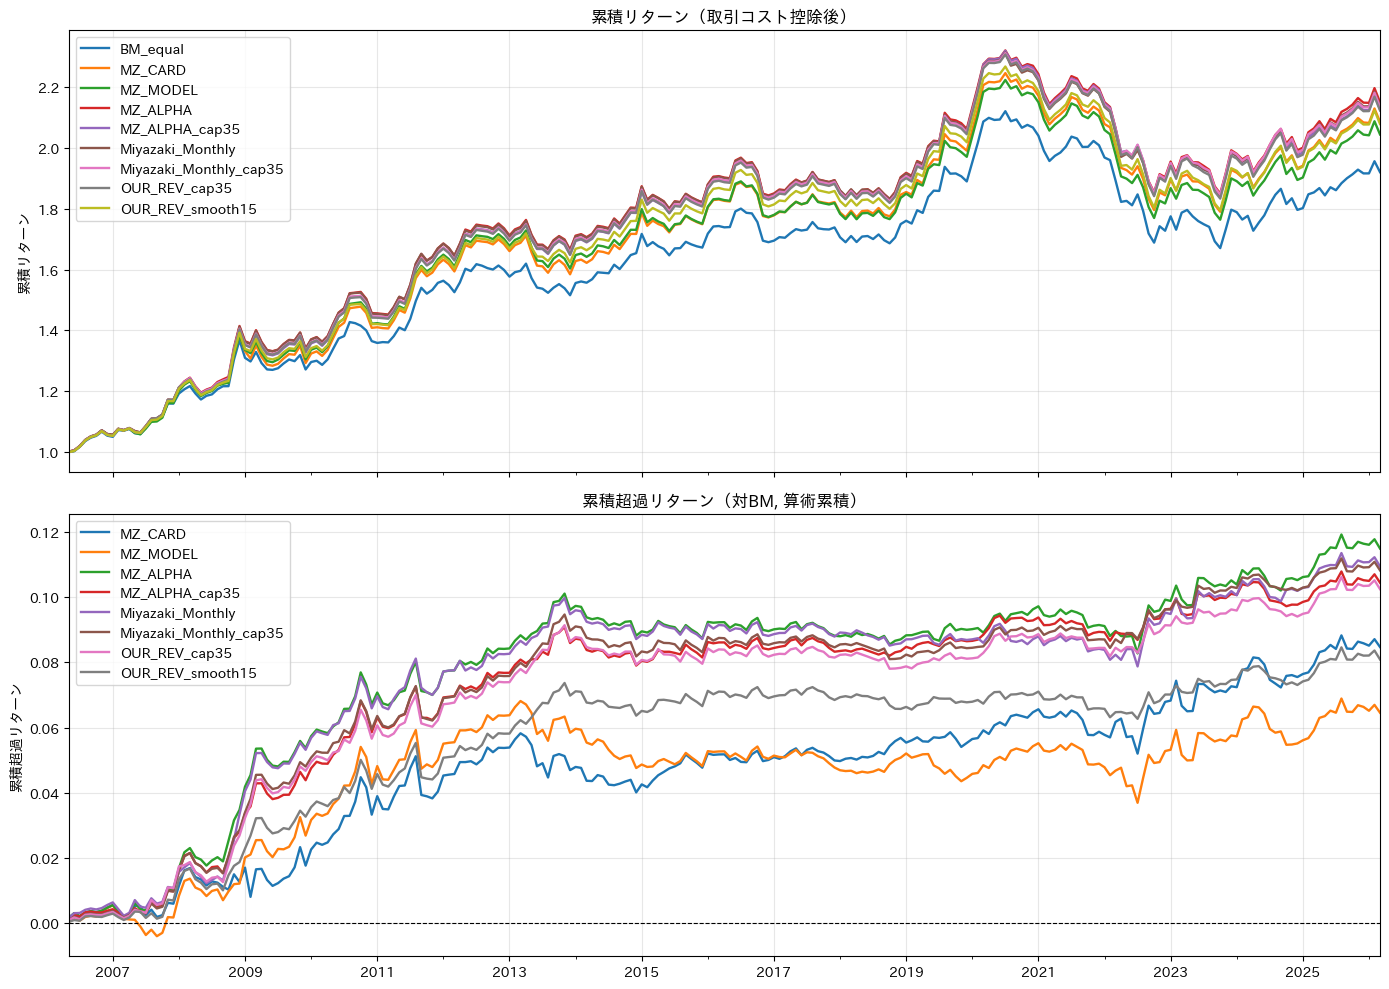

In [10]:
cum_net = (1 + returns_net).cumprod()
alpha_cum_net = returns_net.sub(returns_net["BM_equal"], axis=0).cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

cum_net.plot(ax=axes[0], linewidth=1.7)
axes[0].set_title("累積リターン（取引コスト控除後）")
axes[0].set_ylabel("累積リターン")
axes[0].grid(True, alpha=0.3)

alpha_cum_net.drop(columns=["BM_equal"]).plot(ax=axes[1], linewidth=1.7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("累積超過リターン（対BM, 算術累積）")
axes[1].set_ylabel("累積超過リターン")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2019〜2021年だけの比較

以前の `02_miyazaki.ipynb` が良く見えた時期に近い期間だけを切り出す。ただしここでも、実現リターンは全戦略共通の1か月リターンにそろえている。

In [11]:
comparison_period = returns_net.loc["2019-04-30":"2021-10-31"]
comparison_summary = summarize_performance(comparison_period)
display(format_performance_table(comparison_summary))

,年率リターン(幾何),年率ボラ,最大DD,年率超過(算術),TE,IR,勝率
BM_equal,4.34,5.81,-7.72,NaN,NaN,NaN,NaN
MZ_CARD,4.36,5.96,-7.50,0.03,0.59,0.05,51.61
MZ_MODEL,4.24,5.86,-7.48,-0.10,0.59,-0.17,51.61
MZ_ALPHA,4.41,5.91,-7.60,0.07,0.59,0.12,58.06
MZ_ALPHA_cap35,4.45,5.92,-7.78,0.11,0.47,0.23,64.52
Miyazaki_Monthly,4.17,5.89,-8.02,-0.16,0.57,-0.29,58.06
Miyazaki_Monthly_cap35,4.49,5.85,-7.66,0.14,0.46,0.31,70.97
OUR_REV_cap35,4.53,5.89,-7.68,0.18,0.47,0.39,70.97
OUR_REV_smooth15,4.29,5.84,-7.74,-0.05,0.43,-0.12,58.06


## サブ期間分析

市場局面ごとに、Miyazaki型と前回提案型の効き方を確認する。

In [12]:
subperiods = {
    "2006-05〜2009-12": ("2006-05-31", "2009-12-31"),
    "2010-01〜2019-12": ("2010-01-31", "2019-12-31"),
    "2020-01〜2021-12": ("2020-01-31", "2021-12-31"),
    "2022-01〜2026-03": ("2022-01-31", "2026-03-31"),
}

sub_rows = []
for label, (start, end) in subperiods.items():
    sub = returns_net.loc[start:end]
    if len(sub) == 0:
        continue
    summary = summarize_performance(sub)
    for strategy in summary.index:
        row = summary.loc[strategy].copy()
        row.name = (label, strategy)
        sub_rows.append(row)

sub_summary = pd.DataFrame(sub_rows)
sub_summary.index = pd.MultiIndex.from_tuples(sub_summary.index, names=["期間", "戦略"])
display(format_performance_table(sub_summary))

年率リターン(幾何)  年率ボラ   最大DD  年率超過(算術)  \
期間              戦略                                                          
2006-05〜2009-12 BM_equal                      6.78  7.02  -7.14       NaN   
                MZ_CARD                       7.25  7.45  -7.27      0.48   
                MZ_MODEL                      7.53  7.31  -6.37      0.73   
                MZ_ALPHA                      8.31  7.41  -5.86      1.46   
                MZ_ALPHA_cap35                8.02  7.43  -6.21      1.19   
                Miyazaki_Monthly              8.29  7.46  -5.78      1.45   
                Miyazaki_Monthly_cap35        8.15  7.40  -5.96      1.31   
                OUR_REV_cap35                 8.11  7.41  -5.92      1.27   
                OUR_REV_smooth15              7.71  7.30  -6.31      0.89   
2010-01〜2019-12 BM_equal                      4.04  5.07  -6.41       NaN   
                MZ_CARD                       4.42  5.42  -7.41      0.38   
                MZ_MODEL                      4.21  5.39  -7.26      0.18   
                MZ_ALPHA                      4.41  5.33  -6.90      0.36   
                MZ_ALPHA_cap35                4.47  5.32  -6.63      0.43   
                Miyazaki_Monthly              4.38  5.30  -6.83      0.34   
                Miyazaki_Monthly_cap35        4.41  5.27  -6.84      0.36   
                OUR_REV_cap35                 4.39  5.26  -6.79      0.34   
                OUR_REV_smooth15              4.40  5.23  -6.63      0.35   
2020-01〜2021-12 BM_equal                      3.10  5.48  -7.72       NaN   
                MZ_CARD                       3.26  5.65  -7.50      0.17   
                MZ_MODEL                      3.31  5.64  -7.48      0.22   
                MZ_ALPHA                      3.17  5.49  -7.60      0.07   
                MZ_ALPHA_cap35                3.24  5.57  -7.78      0.14   
                Miyazaki_Monthly              2.95  5.53  -8.02     -0.14   
                Miyazaki_Monthly_cap35        3.24  5.49  -7.66      0.14   
                OUR_REV_cap35                 3.26  5.53  -7.68      0.17   
                OUR_REV_smooth15              3.00  5.50  -7.74     -0.09   
2022-01〜2026-03 BM_equal                     -1.05  6.85 -15.13       NaN   
                MZ_CARD                      -0.42  6.45 -13.87      0.61   
                MZ_MODEL                     -0.67  6.57 -14.33      0.37   
                MZ_ALPHA                     -0.49  6.59 -13.98      0.55   
                MZ_ALPHA_cap35               -0.69  6.69 -14.17      0.36   
                Miyazaki_Monthly             -0.44  6.57 -13.63      0.60   
                Miyazaki_Monthly_cap35       -0.55  6.74 -13.81      0.50   
                OUR_REV_cap35                -0.63  6.77 -14.20      0.42   
                OUR_REV_smooth15             -0.70  6.77 -14.45      0.35   

                                          TE    IR     勝率  
期間              戦略                                         
2006-05〜2009-12 BM_equal                 NaN   NaN    NaN  
                MZ_CARD                 1.08  0.45  56.82  
                MZ_MODEL                0.96  0.76  59.09  
                MZ_ALPHA                0.99  1.48  61.36  
                MZ_ALPHA_cap35          0.88  1.35  63.64  
                Miyazaki_Monthly        1.00  1.45  63.64  
                Miyazaki_Monthly_cap35  0.89  1.47  61.36  
                OUR_REV_cap35           0.88  1.44  61.36  
                OUR_REV_smooth15        0.78  1.14  61.36  
2010-01〜2019-12 BM_equal                 NaN   NaN    NaN  
                MZ_CARD                 0.91  0.41  59.17  
                MZ_MODEL                0.92  0.19  55.00  
                MZ_ALPHA                0.80  0.46  56.67  
                MZ_ALPHA_cap35          0.77  0.56  56.67  
                Miyazaki_Monthly        0.79  0.42  55.83  
                Miyazaki_Monthly_cap35  0.77  0.47  53.33  
                OUR_REV_cap35    

## ウエイト推移の比較

`MZ_ALPHA_cap35` と `OUR_REV_cap35` は、どちらも残差を使い、同じ35%上限制約を持つ。シグナルホライズンの違いがウエイト選択にどう出るかを見る。

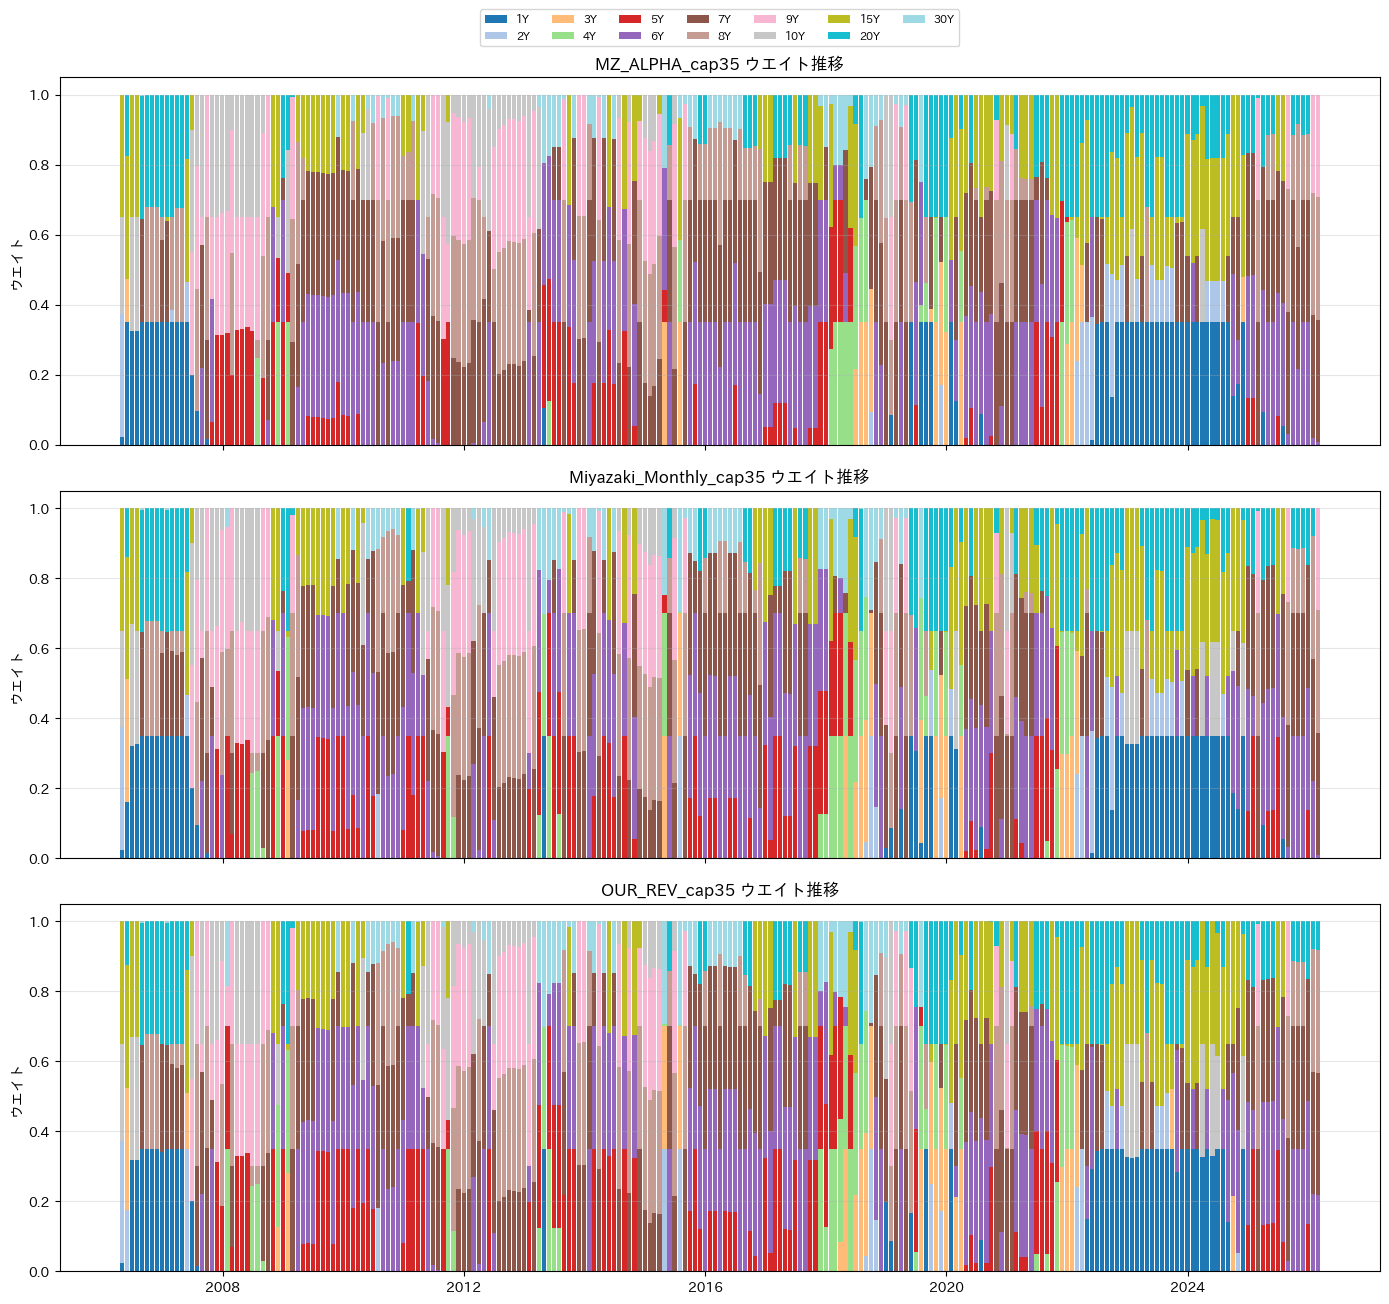

直近のMZ_ALPHA_cap35


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2025-10-31,0.0,0.0,0.0,0.0,0.0,0.216367,0.35,0.350000,0.000000,0.0,0.0,0.083633,0.0
2025-11-30,0.0,0.0,0.0,0.0,0.0,0.350000,0.35,0.185028,0.000000,0.0,0.0,0.114972,0.0
2025-12-31,0.0,0.0,0.0,0.0,0.0,0.350000,0.35,0.187708,0.000000,0.0,0.0,0.112292,0.0
2026-01-31,0.0,0.0,0.0,0.0,0.0,0.020387,0.35,0.350000,0.279613,0.0,0.0,0.000000,0.0
2026-02-28,0.0,0.0,0.0,0.0,0.0,0.007412,0.35,0.350000,0.292588,0.0,0.0,0.000000,0.0


直近のMiyazaki_Monthly_cap35


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2025-10-31,0.0,0.0,0.0,0.0,0.000000,0.350000,0.35,0.184210,0.000000,0.0,0.0,0.115790,0.0
2025-11-30,0.0,0.0,0.0,0.0,0.000000,0.350000,0.35,0.185028,0.000000,0.0,0.0,0.114972,0.0
2025-12-31,0.0,0.0,0.0,0.0,0.136362,0.350000,0.35,0.000000,0.000000,0.0,0.0,0.163638,0.0
2026-01-31,0.0,0.0,0.0,0.0,0.000000,0.219892,0.35,0.350000,0.000000,0.0,0.0,0.080108,0.0
2026-02-28,0.0,0.0,0.0,0.0,0.000000,0.007412,0.35,0.350000,0.292588,0.0,0.0,0.000000,0.0


直近のOUR_REV_cap35


,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,15Y,20Y,30Y
2025-10-31,0.0,0.0,0.0,0.0,0.000000,0.350000,0.35,0.184210,0.0,0.0,0.0,0.115790,0.0
2025-11-30,0.0,0.0,0.0,0.0,0.000000,0.350000,0.35,0.185028,0.0,0.0,0.0,0.114972,0.0
2025-12-31,0.0,0.0,0.0,0.0,0.136362,0.350000,0.35,0.000000,0.0,0.0,0.0,0.163638,0.0
2026-01-31,0.0,0.0,0.0,0.0,0.000000,0.219892,0.35,0.350000,0.0,0.0,0.0,0.080108,0.0
2026-02-28,0.0,0.0,0.0,0.0,0.000000,0.216840,0.35,0.350000,0.0,0.0,0.0,0.083160,0.0


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
colors = plt.cm.tab20(np.linspace(0, 1, N_SECTORS))

for ax, strategy in zip(axes, ["MZ_ALPHA_cap35", "Miyazaki_Monthly_cap35", "OUR_REV_cap35"]):
    wdf = weight_dfs[strategy]
    bottom = np.zeros(len(wdf))
    for i, col in enumerate(SECTOR_NAMES):
        ax.bar(wdf.index, wdf[col].values, bottom=bottom, width=25, color=colors[i], label=col)
        bottom += wdf[col].values
    ax.set_title(f"{strategy} ウエイト推移")
    ax.set_ylabel("ウエイト")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis="y")

axes[0].legend(ncol=7, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.20))
plt.tight_layout()
plt.show()

print("直近のMZ_ALPHA_cap35")
display(weight_dfs["MZ_ALPHA_cap35"].tail())
print("直近のMiyazaki_Monthly_cap35")
display(weight_dfs["Miyazaki_Monthly_cap35"].tail())
print("直近のOUR_REV_cap35")
display(weight_dfs["OUR_REV_cap35"].tail())

## 結果保存

比較結果をExcelに保存する。

In [14]:
with pd.ExcelWriter(RESULT_PATH) as writer:
    returns_gross.to_excel(writer, sheet_name="returns_gross")
    returns_net.to_excel(writer, sheet_name="returns_net")
    summary_gross.to_excel(writer, sheet_name="summary_gross")
    summary_net.to_excel(writer, sheet_name="summary_net")
    turnover_df.to_excel(writer, sheet_name="turnover")
    residual_df.to_excel(writer, sheet_name="factor_residuals")
    for name, wdf in weight_dfs.items():
        wdf.to_excel(writer, sheet_name=f"weights_{name}"[:31])

print(f"保存完了: {RESULT_PATH}")

保存完了: ../data/backtest_miyazaki_long_comparison.xlsx


## 読み取り

同じデータ・同じ1か月実現リターンにそろえると、Miyazaki型の誤差項補正は長期でも単純CA&RDを上回る傾向がある。

今回追加した `Miyazaki_Monthly` は、宮崎論文の半年CA&RDを単に6で割るのではなく、シグナル自体を1か月ホライズンで再計算する版である。これにより、短期のロールダウンと月次残差修正により忠実な比較ができる。

結果の読み方としては、`MZ_ALPHA_cap35` と `Miyazaki_Monthly_cap35` の差が「半年ホライズンのMiyazaki型を月次リバランスで使うこと」と「Miyazaki型を完全に月次化すること」の差である。